## Dataset

In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [3]:
print("nums of train:", len(train_data))
print("nums of test:", len(test_data))

nums of train: 50000
nums of test: 10000


In [4]:
image, label = train_data[12]
print("Shape of img:", image.shape)
print("Label:", label)
print("Type:", type(image))

Shape of img: torch.Size([3, 32, 32])
Label: 7
Type: <class 'torch.Tensor'>


In [5]:
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(classes[label])

horse


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.96862745].


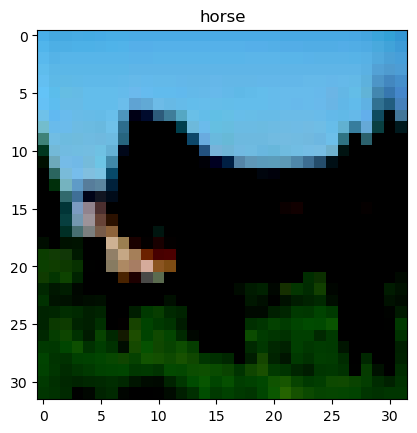

In [6]:
import matplotlib.pyplot as plt
import numpy as np

img = image.permute(1, 2, 0)
plt.imshow(img)
plt.title(classes[label])
plt.show()

In [7]:
print(image.size(0))
print(image.size(1))
print(image.size(2))

3
32
32


## Model (LeNet-5)

In [8]:
import torch.nn as nn
from collections import OrderedDict

class C1(nn.Module):
    def __init__(self):
        super(C1, self).__init__()

        self.c1 = nn.Sequential(OrderedDict([
            ('c1', nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(5, 5))),
            ('relu1', nn.ReLU()),
            ('s1', nn.MaxPool2d(kernel_size=(2, 2), stride=2))
        ]))

    def forward(self, img):
        output = self.c1(img)
        return output


class C2(nn.Module):
    def __init__(self):
        super(C2, self).__init__()

        self.c2 = nn.Sequential(OrderedDict([
            ('c2', nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(5, 5))),
            ('relu2', nn.ReLU()),
            ('s2', nn.MaxPool2d(kernel_size=(2, 2), stride=2))
        ]))

    def forward(self, img):
        output = self.c2(img)
        return output


class C3(nn.Module):
    def __init__(self):
        super(C3, self).__init__()

        self.c3 = nn.Sequential(OrderedDict([
            ('c3', nn.Conv2d(in_channels=16, out_channels=120, kernel_size=(5, 5))),
            ('relu3', nn.ReLU())
        ]))

    def forward(self, img):
        output = self.c3(img)
        return output


class F4(nn.Module):
    def __init__(self):
        super(F4, self).__init__()

        self.f4 = nn.Sequential(OrderedDict([
            ('f4', nn.Linear(in_features=120, out_features=84)),
            ('relu4', nn.ReLU())
        ]))

    def forward(self, img):
        output = self.f4(img)
        return output


class F5(nn.Module):
    def __init__(self):
        super(F5, self).__init__()

        self.f5 = nn.Sequential(OrderedDict([
            ('f5', nn.Linear(in_features=84, out_features=10))
        ]))

    def forward(self, img):
        output = self.f5(img)
        return output


class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.c1 = C1()
        self.c2 = C2()
        self.c3 = C3()
        self.f4 = F4()
        self.f5 = F5()

    def forward(self, img):
        output = self.c1(img)

        output = self.c2(output)
        output = self.c3(output)
        output = output.view(img.size(0), -1)
        output = self.f4(output)
        output = self.f5(output)
        return output

In [9]:
import torch

c1 = C1()
c2 = C2()
c3 = C3()
f4 = F4()
f5 = F5()

x = torch.randn(64, 3, 32, 32)

print("Input:", x.shape)

x = c1(x)
print("After C1:", x.shape)

x = c2(x)
print("After C2:", x.shape)

x = c3(x)
print("After C3:", x.shape)

x = x.view(x.size(0), -1)
print("After flatten:", x.shape)

x = f4(x)
print("After F4:", x.shape)

x = f5(x)
print("After F5:", x.shape)

Input: torch.Size([64, 3, 32, 32])
After C1: torch.Size([64, 6, 14, 14])
After C2: torch.Size([64, 16, 5, 5])
After C3: torch.Size([64, 120, 1, 1])
After flatten: torch.Size([64, 120])
After F4: torch.Size([64, 84])
After F5: torch.Size([64, 10])


## Model Train on Train Dataset

In [10]:
import torch
import torch.optim as optim
model = LeNet5()

In [11]:
for name, param in model.named_parameters():
    print(f"Parametre adı: {name}")
    print(f"Şekli: {param.shape}")
    print(f"Değerler:\n{param}")
    print("-----------")

Parametre adı: c1.c1.c1.weight
Şekli: torch.Size([6, 3, 5, 5])
Değerler:
Parameter containing:
tensor([[[[-6.9209e-02,  1.0566e-01, -6.0120e-02, -1.0273e-02,  2.2095e-02],
          [ 9.9988e-02, -6.5817e-02, -5.7010e-02,  6.5847e-03, -1.1182e-01],
          [ 7.6924e-02, -4.3247e-02,  5.4752e-02, -4.9405e-02, -6.0362e-02],
          [ 1.1308e-01, -8.7597e-02, -9.5949e-02,  1.0954e-01,  7.1232e-02],
          [ 1.0505e-02,  7.0577e-02,  5.1944e-02, -8.5909e-02,  8.9128e-02]],

         [[ 9.8975e-02, -8.3852e-02, -4.1401e-02, -9.7167e-02,  5.5589e-02],
          [-3.9191e-02,  9.8780e-02, -3.3010e-03,  7.7950e-02, -2.3773e-02],
          [-8.1340e-02, -9.1410e-02,  2.0470e-02, -6.7470e-02, -8.6691e-02],
          [ 7.5393e-02,  3.2004e-02,  1.1443e-01,  1.0049e-01, -7.2027e-02],
          [ 4.0940e-02,  4.6040e-03,  5.5086e-02, -8.2178e-02,  1.0872e-01]],

         [[-1.9837e-02,  5.4553e-02, -7.0596e-02, -5.9374e-02, -3.1563e-02],
          [ 6.4326e-02,  6.7959e-02,  7.5512e-02, -6.4

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
for epoch in range(10):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader):.4f}")

Epoch 1, Loss: 1.9678
Epoch 2, Loss: 1.7984
Epoch 3, Loss: 1.7246
Epoch 4, Loss: 1.6851
Epoch 5, Loss: 1.6614
Epoch 6, Loss: 1.6371
Epoch 7, Loss: 1.6216
Epoch 8, Loss: 1.5879
Epoch 9, Loss: 1.5631
Epoch 10, Loss: 1.5508


## Model Test on Test Dataset

In [13]:
model.eval()

correct = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 44.11%


## ResNet18 Model

In [ ]:
import torch
from torchvision import models
import torch.nn as nn
model = models.resnet18(weights = None)

In [ ]:
model.fc = nn.Linear(model.fc.in_features, 10)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
# Test girdisi
x = torch.randn(64, 3, 32, 32).to(device)

print("Input:", x.shape)

# İlk katmanlar
x = model.conv1(x)
print("After conv1:", x.shape)

x = model.bn1(x)
print("After bn1:", x.shape)

x = model.relu(x)
print("After relu:", x.shape)

x = model.maxpool(x)
print("After maxpool:", x.shape)

# Residual katman grupları
x = model.layer1(x)
print("After layer1:", x.shape)

x = model.layer2(x)
print("After layer2:", x.shape)

x = model.layer3(x)
print("After layer3:", x.shape)

x = model.layer4(x)
print("After layer4:", x.shape)

# Son kısım
x = model.avgpool(x)
print("After avgpool:", x.shape)

x = torch.flatten(x, 1)
print("After flatten:", x.shape)

x = model.fc(x)
print("After fc:", x.shape)

In [ ]:
print(model)

In [ ]:
import torch

x = torch.randn(64, 3, 32, 32).to(device)
y = model(x)

print("Output shape:", y.shape)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Learning rate 0.001 olarak belirlendi.

for epoch in range(10):
    model.train()  
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader):.4f}")

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')